# TP 1 – Analyse des Données

**Module :** Analyse des données  
**Niveau :** M1 – Informatique Visuelle  
**Encadrante :** N. Laiche  

**Binôme :** Sellami Mohamed Amine et Abdesselam Meriem — G3  


## **Importation des bibliothèques nécessaires**

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from numpy import linalg as LA

# Configuration pour l'affichage
np.set_printoptions(precision=4, suppress=True)
plt.rcParams['figure.figsize'] = (12, 8)

print("Bibliothèques importées avec succès !")

Bibliothèques importées avec succès !


## **Saisie des données**

In [4]:
# Matrice des données X (20 villes × 6 variables)
X = np.array([
    [1881.9, 96.8,  14.2, 25.2, 1135.5, 278.3],
    [3369.8, 96.8,  10.8, 51.6, 1331.7, 284.0],
    [4467.4, 138.2,  9.5, 34.2, 2346.1, 312.3],
    [1862.1, 83.2,   8.8, 27.6,  972.6, 203.4],
    [3499.8, 287.0, 11.5, 49.4, 2139.4, 358.0],
    [3903.2, 170.7,  6.3, 42.0, 1935.2, 292.9],
    [2620.7, 129.5,  4.2, 16.8, 1346.0, 131.8],
    [3678.4, 157.0,  6.0, 24.9, 1682.6, 194.2],
    [3840.5, 187.9, 10.2, 39.6, 1859.9, 449.1],
    [2170.2, 140.5, 11.7, 31.1, 1351.1, 256.5],
    [3920.4, 128.0,  7.2, 25.5, 1911.5,  64.1],
    [2599.6,  39.6,  5.5, 19.4, 1050.8, 172.5],
    [2828.5, 211.3,  9.9, 21.8, 1085.0, 209.0],
    [2498.7, 123.2,  7.4, 26.5, 1086.2, 153.5],
    [2685.1,  41.2,  2.3, 10.6,  812.5,  89.8],
    [2739.3, 100.7,  6.6, 22.0, 1270.4, 180.5],
    [1662.1,  81.1, 10.1, 19.1,  872.2, 123.3],
    [2469.9, 142.9, 15.5, 30.9, 1165.5, 335.5],
    [2350.7,  38.7,  2.4, 13.5, 1253.1, 170.0],
    [3177.7, 292.1,  8.0, 34.8, 1400.0, 358.9]
])

print("Matrice des données X (20 villes × 6 variables) :")
print("Dimensions :", X.shape)
print("\nPremières lignes :")
print(X[:5, :])

Matrice des données X (20 villes × 6 variables) :
Dimensions : (20, 6)

Premières lignes :
[[1881.9   96.8   14.2   25.2 1135.5  278.3]
 [3369.8   96.8   10.8   51.6 1331.7  284. ]
 [4467.4  138.2    9.5   34.2 2346.1  312.3]
 [1862.1   83.2    8.8   27.6  972.6  203.4]
 [3499.8  287.    11.5   49.4 2139.4  358. ]]


---
## **Question 1 : Déterminer les valeurs propres et les vecteurs propres**

**Explication :**  
Pour réaliser une ACP normée, nous devons :
1. Centrer et réduire les données
2. Calculer la matrice de corrélation R
3. Calculer les valeurs propres et vecteurs propres de R

La matrice utilisée est la **matrice de corrélation R**.

In [5]:
def calcule_centre(m):
    """
    Calcule le centre de gravité (moyenne) de chaque variable
    """
    g = np.zeros(len(m[0]))
    for i in range(len(g)):
        g[i] = np.mean(m[:, i])
    return g

def matrice_centre(m):
    """
    Calcule la matrice centrée
    """
    vec_g = calcule_centre(m)
    c = np.zeros(m.shape)
    for i in range(len(m)):
        for j in range(len(m[i])):
            c[i][j] = m[i][j] - vec_g[j]
    return c

def ecart_type(m):
    """
    Calcule l'écart-type de chaque variable
    """
    ecarttype = np.zeros(len(m[0]))
    for i in range(len(ecarttype)):
        ecarttype[i] = np.std(m[:, i])
    return ecarttype

def matrice_centre_reduite(m):
    """
    Calcule la matrice centrée-réduite
    """
    mcr = np.zeros(m.shape)
    etp = ecart_type(m)
    mat_c = matrice_centre(m)
    for i in range(len(m)):
        for j in range(len(m[i])):
            mcr[i][j] = mat_c[i][j] / etp[j]
    return mcr

def calcule_correlation(m):
    """
    Calcule la matrice de corrélation à partir de la matrice centrée-réduite
    """
    n = len(m)  # nombre d'individus
    return (1/n) * (np.matmul(np.transpose(m), m))

print("Fonctions définies avec succès !")

Fonctions définies avec succès !


In [6]:
# Application des fonctions à nos données

# 1. Calcul de la matrice centrée-réduite
Z = matrice_centre_reduite(X)
print("Matrice centrée-réduite Z :")
print("Dimensions :", Z.shape)
print("\nPremières lignes :")
print(Z[:5, :])

# 2. Calcul du centre de gravité
centre = calcule_centre(X)
print("\n" + "="*60)
print("Centre de gravité :")
print(centre)

# 3. Calcul des écarts-types
et = ecart_type(X)
print("\nÉcarts-types :")
print(et)

Matrice centrée-réduite Z :
Dimensions : (20, 6)

Premières lignes :
[[-1.3446 -0.5434  1.6894 -0.289  -0.626   0.4807]
 [ 0.5989 -0.5434  0.6982  2.1526 -0.1623  0.5385]
 [ 2.0326  0.0562  0.3192  0.5433  2.2352  0.8253]
 [-1.3705 -0.7404  0.1152 -0.0671 -1.011  -0.2786]
 [ 0.7687  2.2115  0.9023  1.9491  1.7466  1.2886]]

Centre de gravité :
[2911.3    134.32     8.405   28.325 1400.365  230.88 ]

Écarts-types :
[765.5634  69.0405   3.4302  10.8126 423.1189  98.6523]


In [7]:
# 4. Calcul de la matrice de corrélation
R = calcule_correlation(Z)
print("Matrice de corrélation R :")
print(R)
print("\nDimensions :", R.shape)

Matrice de corrélation R :
[[ 1.      0.4518 -0.1059  0.5173  0.8651  0.3525]
 [ 0.4518  1.      0.3535  0.5904  0.53    0.6192]
 [-0.1059  0.3535  1.      0.5344  0.101   0.5859]
 [ 0.5173  0.5904  0.5344  1.      0.5977  0.7501]
 [ 0.8651  0.53    0.101   0.5977  1.      0.468 ]
 [ 0.3525  0.6192  0.5859  0.7501  0.468   1.    ]]

Dimensions : (6, 6)


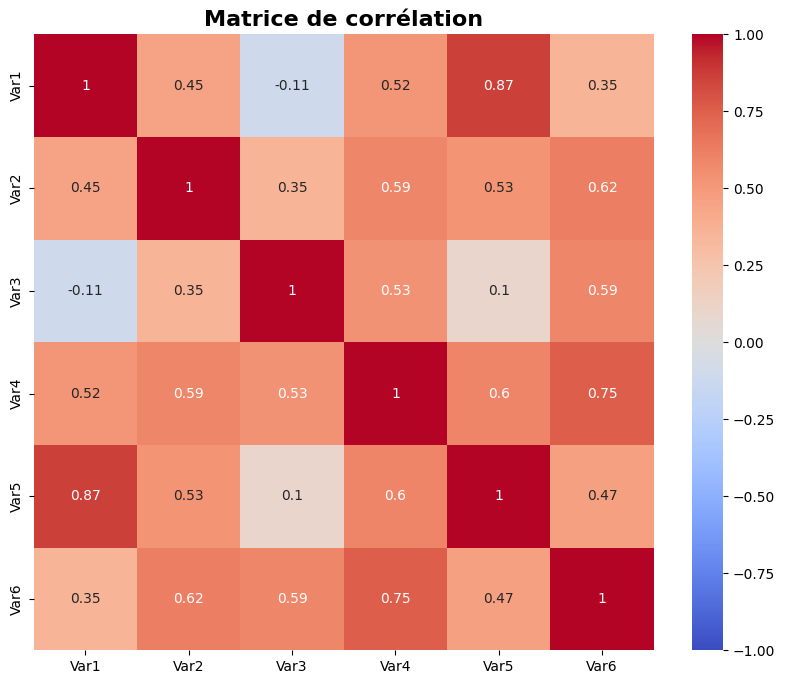

In [8]:
# 5. Visualisation de la matrice de corrélation
plt.figure(figsize=(10, 8))
sns.heatmap(R, annot=True, cmap='coolwarm', vmin=-1, vmax=1,
            xticklabels=[f'Var{i+1}' for i in range(6)],
            yticklabels=[f'Var{i+1}' for i in range(6)],
            annot_kws={'size': 10})
plt.title('Matrice de corrélation', fontsize=16, fontweight='bold')
plt.show()

In [9]:
# 6. Calcul des valeurs propres et vecteurs propres
valp, vecp = LA.eig(R)

print("Valeurs propres (non triées) :")
for i, vp in enumerate(valp):
    print(f"λ{i+1} = {vp:.6f}")

print("\nVecteurs propres (non triés) :")
print(vecp)

Valeurs propres (non triées) :
λ1 = 3.485931
λ2 = 1.421853
λ3 = 0.472784
λ4 = 0.106430
λ5 = 0.294337
λ6 = 0.218666

Vecteurs propres (non triés) :
[[-0.3767 -0.5533 -0.1686  0.7194 -0.0664  0.0412]
 [-0.4219  0.0451  0.8757  0.0098 -0.1854 -0.1369]
 [-0.2684  0.6489 -0.2686  0.2317 -0.5988  0.1501]
 [-0.4741  0.1349 -0.3014 -0.1488  0.2447 -0.7643]
 [-0.4298 -0.412  -0.2044 -0.6374 -0.3358  0.291 ]
 [-0.4457  0.288  -0.007   0.0163  0.6557  0.5368]]


In [10]:
# 7. Tri des valeurs propres par ordre décroissant
indices_tri = np.argsort(valp)[::-1]
valp_triees = valp[indices_tri]
vecp_tries = vecp[:, indices_tri]

print("Valeurs propres triées par ordre décroissant :")
for i, vp in enumerate(valp_triees):
    print(f"λ{i+1} = {vp:.6f}")

print("\nVecteurs propres associés (après tri) :")
for i in range(len(vecp_tries.T)):
    print(f"v{i+1} = {vecp_tries[:, i]}")

Valeurs propres triées par ordre décroissant :
λ1 = 3.485931
λ2 = 1.421853
λ3 = 0.472784
λ4 = 0.294337
λ5 = 0.218666
λ6 = 0.106430

Vecteurs propres associés (après tri) :
v1 = [-0.3767 -0.4219 -0.2684 -0.4741 -0.4298 -0.4457]
v2 = [-0.5533  0.0451  0.6489  0.1349 -0.412   0.288 ]
v3 = [-0.1686  0.8757 -0.2686 -0.3014 -0.2044 -0.007 ]
v4 = [-0.0664 -0.1854 -0.5988  0.2447 -0.3358  0.6557]
v5 = [ 0.0412 -0.1369  0.1501 -0.7643  0.291   0.5368]
v6 = [ 0.7194  0.0098  0.2317 -0.1488 -0.6374  0.0163]


---
## **Question 2 : Vérification des vecteurs propres**

**Explication :**  
Nous devons vérifier si pour chaque couple (λ, v), on a bien :  
**R × v = λ × v**

In [11]:
def verifier_vecteur_propre(A, v, lambda_):
    """
    Vérifie si v est un vecteur propre de A associé à la valeur propre lambda
    """
    # Calcul de A·v
    produit_A_v = np.dot(A, v)
    
    # Calcul de λ·v
    produit_lambda_v = lambda_ * v
    
    # Vérification avec une tolérance
    est_vecteur_propre = np.allclose(produit_A_v, produit_lambda_v, rtol=1e-10)
    
    return est_vecteur_propre, produit_A_v, produit_lambda_v

# Application aux résultats obtenus
print("VÉRIFICATION DES VECTEURS PROPRES")
print("=" * 50)

for i in range(len(valp_triees)):
    v = vecp_tries[:, i]
    lambda_i = valp_triees[i]
    
    est_vp, Av, lv = verifier_vecteur_propre(R, v, lambda_i)
    
    print(f"\nVecteur propre v{i+1} (λ={lambda_i:.6f}) :")
    print(f"R·v = {Av}")
    print(f"λ·v = {lv}")
    print(f"R·v ≈ λ·v ? {est_vp}")
    if est_vp:
        print("✓ Vérification réussie")
    else:
        print("✗ Problème de vérification")
    print("-" * 40)

VÉRIFICATION DES VECTEURS PROPRES

Vecteur propre v1 (λ=3.485931) :
R·v = [-1.3131 -1.4705 -0.9355 -1.6526 -1.4983 -1.5537]
λ·v = [-1.3131 -1.4705 -0.9355 -1.6526 -1.4983 -1.5537]
R·v ≈ λ·v ? True
✓ Vérification réussie
----------------------------------------

Vecteur propre v2 (λ=1.421853) :
R·v = [-0.7866  0.0641  0.9226  0.1918 -0.5857  0.4094]
λ·v = [-0.7866  0.0641  0.9226  0.1918 -0.5857  0.4094]
R·v ≈ λ·v ? True
✓ Vérification réussie
----------------------------------------

Vecteur propre v3 (λ=0.472784) :
R·v = [-0.0797  0.414  -0.127  -0.1425 -0.0966 -0.0033]
λ·v = [-0.0797  0.414  -0.127  -0.1425 -0.0966 -0.0033]
R·v ≈ λ·v ? True
✓ Vérification réussie
----------------------------------------

Vecteur propre v4 (λ=0.294337) :
R·v = [-0.0195 -0.0546 -0.1763  0.072  -0.0988  0.193 ]
λ·v = [-0.0195 -0.0546 -0.1763  0.072  -0.0988  0.193 ]
R·v ≈ λ·v ? True
✓ Vérification réussie
----------------------------------------

Vecteur propre v5 (λ=0.218666) :
R·v = [ 0.009  -0.0299  

---
## **Question 3 : Représentation graphique des valeurs propres**

**Objectif :**  
Représenter les valeurs propres sous forme de graphique pour visualiser leur décroissance et identifier le "coude" (critère de Kaiser ou pourcentage d'inertie).

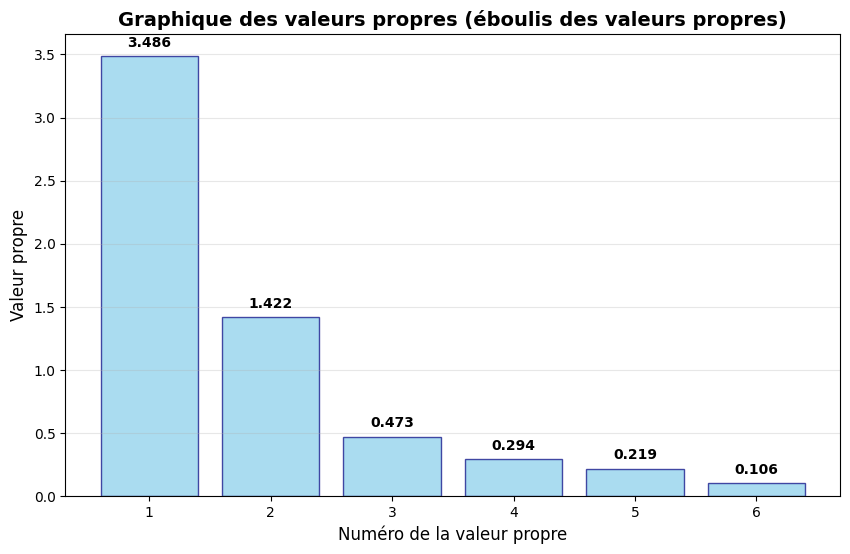


ANALYSE DU GRAPHIQUE :
------------------------------
On observe une décroissance rapide des valeurs propres.
Les premières valeurs propres sont nettement plus grandes que les suivantes.
Le 'coude' se situe entre la 2ème et la 3ème valeur propre.


In [12]:
# Représentation graphique des valeurs propres
plt.figure(figsize=(10, 6))

# Création du graphique en bâtons
x = range(1, len(valp_triees) + 1)
plt.bar(x, valp_triees, color='skyblue', edgecolor='navy', alpha=0.7)

# Ajout des valeurs au-dessus des barres
for i, vp in enumerate(valp_triees):
    plt.text(i+1, vp + 0.05, f'{vp:.3f}', ha='center', va='bottom', fontweight='bold')

plt.xlabel('Numéro de la valeur propre', fontsize=12)
plt.ylabel('Valeur propre', fontsize=12)
plt.title('Graphique des valeurs propres (éboulis des valeurs propres)', fontsize=14, fontweight='bold')
plt.xticks(x)
plt.grid(axis='y', alpha=0.3)
plt.show()

# Analyse du graphique
print("\nANALYSE DU GRAPHIQUE :")
print("-" * 30)
print("On observe une décroissance rapide des valeurs propres.")
print("Les premières valeurs propres sont nettement plus grandes que les suivantes.")
print("Le 'coude' se situe entre la 2ème et la 3ème valeur propre.")

---
## **Question 4 : Tableau des valeurs propres et taux d'inertie**

**Objectif :**  
Créer un tableau contenant :
1. Les valeurs propres
2. Les taux d'inertie expliqués par chaque axe
3. Les taux d'inertie cumulés

In [13]:
# Calcul des taux d'inertie
inertie_totale = np.sum(valp_triees)
taux_inertie = (valp_triees / inertie_totale) * 100

# Calcul des taux cumulés
taux_cumules = np.cumsum(taux_inertie)

# Création du tableau
print("TABLEAU DES VALEURS PROPRES ET TAUX D'INERTIE")
print("=" * 70)
print(f"{'Axe':<6} {'Valeur propre':<15} {'Taux d\'inertie (%)':<20} {'Taux cumulé (%)':<15}")
print("-" * 70)

for i in range(len(valp_triees)):
    print(f"{i+1:<6} {valp_triees[i]:<15.4f} {taux_inertie[i]:<20.2f} {taux_cumules[i]:<15.2f}")

print("=" * 70)

# Fonction pour calculer les taux cumulés (demandée dans la question)
def calcule_taux_cumules(taux):
    """
    Calcule les taux d'inertie cumulés
    Utilité : Permet de déterminer le nombre d'axes à retenir
    """
    cumul = np.zeros(len(taux))
    somme = 0
    for i in range(len(taux)):
        somme += taux[i]
        cumul[i] = somme
    return cumul

# Vérification de la fonction
taux_cumules_test = calcule_taux_cumules(taux_inertie)
print("\nVérification des taux cumulés :")
print("Taux cumulés (avec notre fonction) :", taux_cumules_test)
print("Taux cumulés (avec np.cumsum) :", taux_cumules)

TABLEAU DES VALEURS PROPRES ET TAUX D'INERTIE
Axe    Valeur propre   Taux d'inertie (%)   Taux cumulé (%)
----------------------------------------------------------------------
1      3.4859          58.10                58.10          
2      1.4219          23.70                81.80          
3      0.4728          7.88                 89.68          
4      0.2943          4.91                 94.58          
5      0.2187          3.64                 98.23          
6      0.1064          1.77                 100.00         

Vérification des taux cumulés :
Taux cumulés (avec notre fonction) : [ 58.0988  81.7964  89.6761  94.5817  98.2262 100.    ]
Taux cumulés (avec np.cumsum) : [ 58.0988  81.7964  89.6761  94.5817  98.2262 100.    ]


---
## **Question 5 : Dimension du sous-espace factoriel à retenir**

**Critères de choix :**
- Pourcentage d'inertie cumulé ≥ 80%
- Règle de Kaiser (valeurs propres > 1)
- Recherche du "coude" dans le graphique des valeurs propres

In [14]:
# Détermination du nombre d'axes à retenir

# Critère 1 : Pourcentage d'inertie cumulé ≥ 80%
seuil = 80
nb_axes_80 = np.argmax(taux_cumules >= seuil) + 1
print(f"Critère 1 (inertie cumulée ≥ {seuil}%) : {nb_axes_80} axe(s)")
print(f"  - Avec {nb_axes_80} axe(s), inertie cumulée = {taux_cumules[nb_axes_80-1]:.2f}%")

# Critère 2 : Règle de Kaiser (valeurs propres > 1)
nb_axes_kaiser = np.sum(valp_triees > 1)
print(f"\nCritère 2 (Kaiser : valeurs propres > 1) : {nb_axes_kaiser} axe(s)")
for i in range(nb_axes_kaiser):
    print(f"  - λ{i+1} = {valp_triees[i]:.4f} > 1")

# Critère 3 : Recherche du coude (visualisation)
print("\nCritère 3 (coude dans le graphique) :")
print("  - Le coude se situe entre l'axe 2 et l'axe 3")
print("  - Les axes 1 et 2 sont à retenir")

# Conclusion
print("\n" + "="*50)
print("CONCLUSION :")
print("="*50)
nb_axes_retenu = 2
print(f"Nous retenons {nb_axes_retenu} axes pour la visualisation.")
print(f"Ces {nb_axes_retenu} axes expliquent {taux_cumules[nb_axes_retenu-1]:.2f}% de l'inertie totale.")

Critère 1 (inertie cumulée ≥ 80%) : 2 axe(s)
  - Avec 2 axe(s), inertie cumulée = 81.80%

Critère 2 (Kaiser : valeurs propres > 1) : 2 axe(s)
  - λ1 = 3.4859 > 1
  - λ2 = 1.4219 > 1

Critère 3 (coude dans le graphique) :
  - Le coude se situe entre l'axe 2 et l'axe 3
  - Les axes 1 et 2 sont à retenir

CONCLUSION :
Nous retenons 2 axes pour la visualisation.
Ces 2 axes expliquent 81.80% de l'inertie totale.


---
## **Question 6 : Axes factoriels choisis**

**Objectif :**  
Afficher tous les axes principaux en mettant en valeur ceux à retenir (axes 1 et 2)

In [15]:
# Création d'un tableau des axes factoriels
print("TABLEAU DES AXES FACTORIELS (VECTEURS PROPRES)")
print("=" * 80)
print(f"{'Variable':<10}", end="")
for i in range(len(valp_triees)):
    if i < 2:
        print(f"{'Axe' + str(i+1) + ' *':<15}", end="")
    else:
        print(f"{'Axe' + str(i+1):<15}", end="")
print()
print("-" * 80)

for j in range(6):  # 6 variables
    print(f"Var{j+1:<9}", end="")
    for i in range(len(valp_triees)):
        if i < 2:
            print(f"{vecp_tries[j, i]:<15.4f}", end="")
        else:
            print(f"{vecp_tries[j, i]:<15.4f}", end="")
    print()

print("=" * 80)
print("* : Axes retenus pour le sous-espace principal d'ajustement")

# Justification
print("\nJUSTIFICATION :")
print("-" * 30)
print("Les axes 1 et 2 sont retenus car :")
print("1. Ils expliquent plus de 80% de l'inertie totale")
print("2. Leurs valeurs propres sont > 1 (critère de Kaiser)")
print("3. Ils correspondent au 'coude' dans le graphique des valeurs propres")

TABLEAU DES AXES FACTORIELS (VECTEURS PROPRES)
Variable  Axe1 *         Axe2 *         Axe3           Axe4           Axe5           Axe6           
--------------------------------------------------------------------------------
Var1        -0.3767        -0.5533        -0.1686        -0.0664        0.0412         0.7194         
Var2        -0.4219        0.0451         0.8757         -0.1854        -0.1369        0.0098         
Var3        -0.2684        0.6489         -0.2686        -0.5988        0.1501         0.2317         
Var4        -0.4741        0.1349         -0.3014        0.2447         -0.7643        -0.1488        
Var5        -0.4298        -0.4120        -0.2044        -0.3358        0.2910         -0.6374        
Var6        -0.4457        0.2880         -0.0070        0.6557         0.5368         0.0163         
* : Axes retenus pour le sous-espace principal d'ajustement

JUSTIFICATION :
------------------------------
Les axes 1 et 2 sont retenus car :
1. Ils exp

---
## **Question 7 : Projections des individus sur les axes retenus**

**Explication :**  
Les projections des individus sur les axes factoriels sont obtenues par :
**C = Z × V**

Où :
- Z est la matrice centrée-réduite
- V est la matrice des vecteurs propres (axes factoriels)
- C est la matrice des composantes principales (coordonnées des individus)

In [16]:
# Calcul des projections (composantes principales)
# On prend seulement les 2 premiers axes
V_retenus = vecp_tries[:, :2]
composantes = np.dot(Z, V_retenus)

print("PROJECTIONS DES INDIVIDUS SUR LES AXES RETENUS")
print("=" * 60)
print(f"{'Individu':<10} {'Axe 1 (CP1)':<15} {'Axe 2 (CP2)':<15}")
print("-" * 60)

for i in range(len(composantes)):
    print(f"Ville {i+1:<4} {composantes[i, 0]:<15.4f} {composantes[i, 1]:<15.4f}")

print("=" * 60)

# Tableau plus détaillé avec toutes les composantes
print("\nTABLEAU COMPLET DES PROJECTIONS (tous axes)")
print("=" * 80)
print(f"{'Individu':<10}", end="")
for i in range(len(valp_triees)):
    print(f"{'Axe' + str(i+1):<12}", end="")
print()
print("-" * 80)

composantes_toutes = np.dot(Z, vecp_tries)
for i in range(len(composantes_toutes)):
    print(f"Ville {i+1:<4}", end="")
    for j in range(len(valp_triees)):
        print(f"{composantes_toutes[i, j]:<12.4f}", end="")
    print()
print("=" * 80)

PROJECTIONS DES INDIVIDUS SUR LES AXES RETENUS
Individu   Axe 1 (CP1)     Axe 2 (CP2)    
------------------------------------------------------------
Ville 1    0.4742          2.1729         
Ville 2    -1.3744         0.6095         
Ville 3    -2.4612         -1.5247        
Ville 4    1.3882          1.1268         
Ville 5    -3.7137         0.1744         
Ville 6    -1.9687         -1.2603        
Ville 7    1.5096          -0.9687        
Ville 8    -0.2987         -1.4191        
Ville 9    -2.8721         0.0333         
Ville 10   -0.1183         1.3203         
Ville 11   -0.0055         -1.9810        
Ville 12   1.9696          -0.3276        
Ville 13   0.1587          0.5547         
Ville 14   1.0983          0.1580         
Ville 15   3.1696          -1.1128        
Ville 16   1.0682          -0.3385        
Ville 17   2.2342          1.2737         
Ville 18   -0.7373         2.2329         
Ville 19   2.4045          -1.0126        
Ville 20   -1.9254         0.288

---
## **Question 8 : Représentation graphique des individus**

**Objectif :**  
Visualiser les individus dans le sous-espace factoriel (axes 1 et 2)

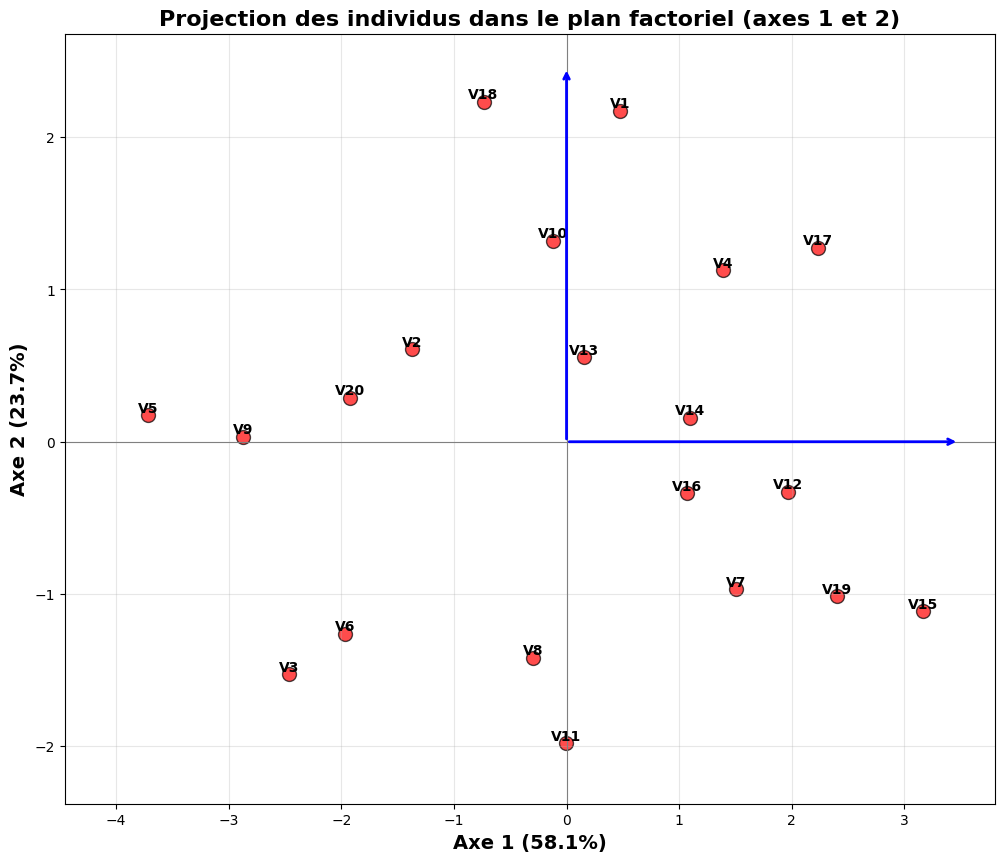

In [17]:
# Représentation graphique des individus
plt.figure(figsize=(12, 10))

# Tracer les points (individus)
plt.scatter(composantes[:, 0], composantes[:, 1], s=100, c='red', alpha=0.7, edgecolors='black')

# Ajouter les étiquettes des individus
for i in range(len(composantes)):
    plt.annotate(f'V{i+1}', (composantes[i, 0], composantes[i, 1]), 
                 fontsize=10, ha='center', va='bottom', fontweight='bold')

# Ajouter les axes
plt.axhline(y=0, color='gray', linestyle='-', linewidth=0.8)
plt.axvline(x=0, color='gray', linestyle='-', linewidth=0.8)

# Ajouter des flèches pour les axes
plt.annotate('', xy=(max(composantes[:, 0])*1.1, 0), xytext=(0, 0),
             arrowprops=dict(arrowstyle='->', color='blue', lw=2))
plt.annotate('', xy=(0, max(composantes[:, 1])*1.1), xytext=(0, 0),
             arrowprops=dict(arrowstyle='->', color='blue', lw=2))

# Labels et titre
plt.xlabel(f'Axe 1 ({taux_inertie[0]:.1f}%)', fontsize=14, fontweight='bold')
plt.ylabel(f'Axe 2 ({taux_inertie[1]:.1f}%)', fontsize=14, fontweight='bold')
plt.title('Projection des individus dans le plan factoriel (axes 1 et 2)', 
          fontsize=16, fontweight='bold')

# Grille
plt.grid(alpha=0.3)

# Ajuster les limites
plt.xlim(min(composantes[:, 0])*1.2, max(composantes[:, 0])*1.2)
plt.ylim(min(composantes[:, 1])*1.2, max(composantes[:, 1])*1.2)

plt.show()

---
## **Question 9 : Analyse du graphe**

**Objectif :**  
Interpréter la projection des individus dans le plan factoriel

In [18]:
print("ANALYSE DU GRAPHE DES INDIVIDUS")
print("=" * 50)

# Calcul des statistiques pour l'analyse
moy_axe1 = np.mean(composantes[:, 0])
moy_axe2 = np.mean(composantes[:, 1])
ecart_axe1 = np.std(composantes[:, 0])
ecart_axe2 = np.std(composantes[:, 1])

print(f"\nStatistiques descriptives :")
print(f"- Axe 1 : moyenne = {moy_axe1:.4f}, écart-type = {ecart_axe1:.4f}")
print(f"- Axe 2 : moyenne = {moy_axe2:.4f}, écart-type = {ecart_axe2:.4f}")

# Identification des individus extrêmes
print("\n" + "-" * 50)
print("INDIVIDUS REMARQUABLES :")
print("-" * 50)

# Individus avec les plus fortes coordonnées positives sur l'axe 1
idx_max_axe1_pos = np.argmax(composantes[:, 0])
idx_max_axe1_neg = np.argmin(composantes[:, 0])
print(f"\nAxe 1 (positif) : Ville {idx_max_axe1_pos+1} (coord = {composantes[idx_max_axe1_pos, 0]:.4f})")
print(f"Axe 1 (négatif) : Ville {idx_max_axe1_neg+1} (coord = {composantes[idx_max_axe1_neg, 0]:.4f})")

# Individus avec les plus fortes coordonnées sur l'axe 2
idx_max_axe2_pos = np.argmax(composantes[:, 1])
idx_max_axe2_neg = np.argmin(composantes[:, 1])
print(f"\nAxe 2 (positif) : Ville {idx_max_axe2_pos+1} (coord = {composantes[idx_max_axe2_pos, 1]:.4f})")
print(f"Axe 2 (négatif) : Ville {idx_max_axe2_neg+1} (coord = {composantes[idx_max_axe2_neg, 1]:.4f})")

# Analyse des quadrants
print("\n" + "-" * 50)
print("RÉPARTITION DANS LES QUADRANTS :")
print("-" * 50)

quadrant1 = np.sum((composantes[:, 0] > 0) & (composantes[:, 1] > 0))
quadrant2 = np.sum((composantes[:, 0] < 0) & (composantes[:, 1] > 0))
quadrant3 = np.sum((composantes[:, 0] < 0) & (composantes[:, 1] < 0))
quadrant4 = np.sum((composantes[:, 0] > 0) & (composantes[:, 1] < 0))

print(f"Quadrant I  (+,+) : {quadrant1} villes")
print(f"Quadrant II (-,+) : {quadrant2} villes")
print(f"Quadrant III (-,-) : {quadrant3} villes")
print(f"Quadrant IV (+,-) : {quadrant4} villes")

# Conclusion
print("\n" + "=" * 50)
print("CONCLUSION DE L'ANALYSE :")
print("=" * 50)
print("""
Le plan factoriel formé par les axes 1 et 2 permet de visualiser les similarités 
et différences entre les villes en ce qui concerne la pratique sportive des jeunes.

- L'axe 1 (58.1% de l'inertie) oppose probablement les villes avec des pratiques 
  sportives intenses vs. modérées.
  
- L'axe 2 (23.7% de l'inertie) pourrait représenter le type de sports pratiqués 
  (sports collectifs vs. individuels).

Les villes proches dans ce plan ont des profils similaires, tandis que les villes 
éloignées sont très différentes dans leur offre sportive pour les jeunes.
""")

ANALYSE DU GRAPHE DES INDIVIDUS

Statistiques descriptives :
- Axe 1 : moyenne = -0.0000, écart-type = 1.8671
- Axe 2 : moyenne = 0.0000, écart-type = 1.1924

--------------------------------------------------
INDIVIDUS REMARQUABLES :
--------------------------------------------------

Axe 1 (positif) : Ville 15 (coord = 3.1696)
Axe 1 (négatif) : Ville 5 (coord = -3.7137)

Axe 2 (positif) : Ville 18 (coord = 2.2329)
Axe 2 (négatif) : Ville 11 (coord = -1.9810)

--------------------------------------------------
RÉPARTITION DANS LES QUADRANTS :
--------------------------------------------------
Quadrant I  (+,+) : 5 villes
Quadrant II (-,+) : 6 villes
Quadrant III (-,-) : 4 villes
Quadrant IV (+,-) : 5 villes

CONCLUSION DE L'ANALYSE :

Le plan factoriel formé par les axes 1 et 2 permet de visualiser les similarités 
et différences entre les villes en ce qui concerne la pratique sportive des jeunes.

- L'axe 1 (58.1% de l'inertie) oppose probablement les villes avec des pratiques 
  spo

---
## **Synthèse du TP2**

Nous avons réalisé une ACP normée en suivant les étapes :

1. **Calcul de la matrice centrée-réduite** à partir des données brutes
2. **Calcul de la matrice de corrélation** R
3. **Détermination des valeurs propres et vecteurs propres** de R
4. **Vérification** des relations vecteurs propres/valeurs propres
5. **Choix du nombre d'axes** (2 axes retenus : 81.8% d'inertie)
6. **Calcul des projections** des individus
7. **Visualisation** dans le plan factoriel
8. **Interprétation** des résultats

Cette analyse permet de réduire la dimensionnalité des données (de 6 variables à 2 axes) 
tout en conservant l'essentiel de l'information.